#### External validation of the GPT task orderings against the APQC Process Classification Framework
#### By: Peyman Shahidi
#### Created: 2026-07-31

**Idea.** Every adjacency object in the paper (chain length, the empirical fragmentation index, the
neighbor-AI regressions) is a function of a single imputation: a GPT-5-mini reconstruction of the order in
which an occupation's O\*NET tasks are performed. The validation currently reported is *internal*, namely
position reshuffles, cross-prompt Kendall tau, and frequency pruning. None of it scores the ordering
instrument against work sequences that people wrote down.

APQC's **Process Classification Framework (PCF)**, Cross-Industry v8.0, supplies that benchmark. The PCF is
a practitioner-authored taxonomy of business processes, built and revised by member working groups since
2004, with no LLM anywhere in its production. It decomposes work into Categories, Process Groups, Processes,
Activities, and Tasks, and within a parent the children are listed in the order in which they are performed:

```
4.2.4 Order materials and services
  .1 Process/Review requisitions        .2 Approve requisitions        .3 Solicit supplier quotes
  .4 Create/Distribute purchase orders  .5 Expedite orders             .6 Reconcile purchase orders
  .7 Research/Resolve order exceptions
```

**The test.** For each PCF parent with at least `MIN_CHILDREN` children we (i) take APQC's published child
order as ground truth, (ii) shuffle the children under a fixed seed, (iii) hand the shuffled list to
GPT-5-mini, and (iv) measure the overlap between the returned ordering and APQC's ordering with Kendall tau,
against a random-permutation null. High overlap says the logic GPT applies when ordering O\*NET tasks, where
no benchmark exists, is the same logic practitioners applied when they wrote down their process sequences.

**All eleven prompts.** A single prompt gives a noisy ordering, so we run the **main prompt (Prompt 0)** and
the **ten alternative prompts** from the prompt-robustness appendix, all eleven over all sibling sets. The
prompts are used verbatim from `onet_task_and_occ_sequence_robustness.ipynb`, with one mechanical
substitution applied identically to all of them: "occupation" becomes "business process" and "task" becomes
"step". Results are reported for the main prompt and for the per-branch average across the ten alternatives.

**Reported splits.** By PCF category, and by APQC's own division into operating processes (Categories 1-6)
and management and support services (Categories 7-13). PCF sibling order is procedural in transactional
branches and closer to a checklist in strategic ones, so the split is reported rather than assumed away.

**Outputs.** `data/computed_objects/apqc_pcf_ordering/`, `writeup/plots/apqc_pcf_ordering/`, and
`writeup/tables/apqc_pcf_ordering_validation.tex`.

In [1]:
#Python
import os, json, glob, warnings
import numpy as np, pandas as pd
from scipy.stats import kendalltau, spearmanr
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 200); pd.set_option('display.width', 220)

In [2]:
MIN_CHILDREN = 3          # sibling sets need >= 3 children for a meaningful rank correlation
N_SHUFFLES   = 1000       # permutation null draws per sibling set
SEED         = 123        # seed for the presentation shuffle and for the null
CHUNK        = 345        # scenarios per EDSL call
RUN_GPT      = True       # set False to reuse the cached orderings only

MAIN_PROMPT  = 'p00'                                   # Prompt 0, the paper's main specification
ALT_PROMPTS  = [f'p{i:02d}' for i in range(1, 11)]     # the ten alternative prompts
PROMPT_IDS   = [MAIN_PROMPT] + ALT_PROMPTS

main_folder_path  = ".."
input_data_path   = f"{main_folder_path}/data"
pcf_file          = f"{input_data_path}/APQC_PCF/APQC_PCF_CrossIndustry_v8.0.xlsx"

output_data_path  = f"{input_data_path}/computed_objects/apqc_pcf_ordering"
gpt_cache_path    = f"{output_data_path}/gpt_orderings"
output_plot_path  = f"{main_folder_path}/writeup/plots/apqc_pcf_ordering"
output_table_path = f"{main_folder_path}/writeup/tables"
for p in [output_data_path, output_plot_path, output_table_path] + [f"{gpt_cache_path}/{v}" for v in PROMPT_IDS]:
    os.makedirs(p, exist_ok=True)

# APQC's own division of the framework
OPERATING_CATS = list(range(1, 7))      # 1-6   operating processes
SUPPORT_CATS   = list(range(7, 14))     # 7-13  management and support services

# 1) Parse the PCF hierarchy and build sibling sets

The `Combined` sheet holds every process element with a persistent `PCF ID`, a positional `Hierarchy ID`
(`4.2.4.3`), a name, and a description. Level is read off the hierarchy ID: `n.0` is a Category (level 1),
`n.m` a Process Group (2), `n.m.k` a Process (3), and so on. A **sibling set** is a parent together with its
ordered children; the child's terminal index is APQC's asserted position in the workflow.

In [3]:
pcf = pd.read_excel(pcf_file, sheet_name='Combined', dtype={'Hierarchy ID': str})
pcf = pcf.rename(columns={'PCF ID': 'pcf_id', 'Hierarchy ID': 'hierarchy_id', 'Name': 'name',
                          'Element Description': 'description', 'Change Details': 'change_details'})
pcf['hierarchy_id'] = pcf['hierarchy_id'].astype(str).str.strip()
pcf['name'] = pcf['name'].astype(str).str.strip()
pcf['description'] = pcf['description'].fillna('').astype(str).str.strip()

def pcf_level(h):
    parts = h.split('.')
    return 1 if (len(parts) == 2 and parts[-1] == '0') else len(parts)

def pcf_parent(h):
    parts, L = h.split('.'), pcf_level(h)
    if L == 1:
        return None
    return f"{parts[0]}.0" if L == 2 else '.'.join(parts[:-1])

pcf['level']       = pcf['hierarchy_id'].map(pcf_level)
pcf['parent_id']   = pcf['hierarchy_id'].map(pcf_parent)
pcf['category']    = pcf['hierarchy_id'].str.split('.').str[0].astype(int)
pcf['child_index'] = pcf['hierarchy_id'].str.split('.').str[-1].astype(int)   # APQC's asserted position
pcf['is_new_v8']   = pcf['change_details'].fillna('').astype(str).str.contains('NEW')

cat_names = dict(pcf.loc[pcf['level'] == 1, ['category', 'name']].values)
pcf['category_name'] = pcf['category'].map(cat_names)

print(f"PCF elements: {len(pcf):,}")
print("level counts:", pcf['level'].value_counts().sort_index().to_dict(),
      " (1 Category, 2 Process Group, 3 Process, 4 Activity, 5 Task)")
print(f"elements new or changed vs v7.4: {int(pcf['change_details'].notna().sum()):,}")
pcf.to_csv(f"{output_data_path}/pcf_elements.csv", index=False)

PCF elements: 2,017
level counts: {1: 13, 2: 74, 3: 362, 4: 1353, 5: 215}  (1 Category, 2 Process Group, 3 Process, 4 Activity, 5 Task)
elements new or changed vs v7.4: 171


In [4]:
# Sibling sets: a parent and its >= MIN_CHILDREN children, in APQC's published order
rng_shuffle = np.random.default_rng(SEED)
parent_lookup = pcf.set_index('hierarchy_id')

sets, rows = {}, []
for parent, g in pcf.dropna(subset=['parent_id']).groupby('parent_id', sort=False):
    if len(g) < MIN_CHILDREN or parent not in parent_lookup.index:
        continue
    g = g.sort_values('child_index').reset_index(drop=True)
    p = parent_lookup.loc[parent]
    sets[parent] = {'parent_name': p['name'], 'parent_level': int(p['level']),
                    'category': int(p['category']), 'category_name': p['category_name'],
                    'children': g[['pcf_id', 'hierarchy_id', 'name', 'description']].to_dict('records'),
                    'present_order': rng_shuffle.permutation(len(g))}   # order shown to the model
    rows.append({'parent_hierarchy_id': parent, 'parent_name': p['name'], 'parent_level': int(p['level']),
                 'category': int(p['category']), 'category_name': p['category_name'], 'n_children': len(g),
                 'share_new_v8': float(g['is_new_v8'].mean())})

sib = pd.DataFrame(rows).sort_values(['category', 'parent_hierarchy_id']).reset_index(drop=True)
sib['segment'] = np.where(sib['category'].isin(OPERATING_CATS), 'Operating (1-6)', 'Mgmt & support (7-13)')
sib.to_csv(f"{output_data_path}/sibling_sets.csv", index=False)

print(f"sibling sets: {len(sib):,} | elements ordered: {sib['n_children'].sum():,} | "
      f"children per set: mean {sib['n_children'].mean():.2f}, median {sib['n_children'].median():.0f}, "
      f"max {sib['n_children'].max()}")
print("\nby parent level:\n", sib['parent_level'].value_counts().sort_index().to_string())
print("\nby segment:\n", sib['segment'].value_counts().to_string())

sibling sets: 345 | elements ordered: 1,917 | children per set: mean 5.56, median 5, max 16

by parent level:
 parent_level
1     13
2     67
3    226
4     39

by segment:
 segment
Mgmt & support (7-13)    208
Operating (1-6)          137


# 2) GPT-5-mini orderings under all eleven prompts

The prompt bodies are copied verbatim from `onet_task_and_occ_sequence_robustness.ipynb`: Prompt 0 is the
main specification used throughout the paper, Prompts 1-10 are the alternatives behind the prompt-robustness
appendix. One mechanical substitution is applied identically to all eleven, mapping the occupation domain
onto the process domain ("occupation" to "business process", "task" to "step"), so that no prompt is
privileged by hand-tuning. Children are presented in the seeded shuffle, never in APQC's order, so the model
cannot anchor on the input sequence. Orderings are cached one CSV per prompt per sibling set, so reruns cost
nothing.

In [5]:
from dotenv import load_dotenv
load_dotenv(f"{main_folder_path}/.env")
from edsl import QuestionFreeText, Scenario, Model
from textwrap import dedent

# Prompt scaffolding and the eleven user prompts, verbatim from onet_task_and_occ_sequence_robustness.ipynb
PREFIX = dedent("""\
    You are an expert in workflow analysis for the occupation: {{ occupation }}.
    Below is a list of {{ num_tasks }} tasks that are part of this occupation:
    {{ tasks_list }}
    """)
RETURN_SPEC = dedent("""\
    Return your answer as a JSON array where each element has:
    - "Task Position": the sequence number (1, 2, 3, etc.)
    - "Task Title": the exact task text from the list above
    Format: [{"Task Position": 1, "Task Title": "..."}, {"Task Position": 2, "Task Title": "..."}, ...]
    Only return the JSON array, nothing else.
    """)
USER_PROMPTS = [
    # 0. Main spec, the prompt used throughout the paper
    'Provide the typical sequential order in which these tasks are performed in a real-world workflow.',
    # 1. Narrative / temporal
    'Imagine a typical workday for this occupation. As the day unfolds, tasks arise and are completed as needed. Order the tasks in the sequence they most naturally occur.',
    # 2. Input-output logic
    'For each task, consider its inputs and outputs. Order tasks so outputs of earlier tasks plausibly feed into later tasks. If tasks are parallel, place the more upstream task first.',
    # 3. Efficiency without templates
    'Order tasks to minimize rework, waiting, and unnecessary handoffs. Assume an experienced worker executing the workflow efficiently.',
    # 4. Backward reasoning, then forward
    'Think about what must ultimately be produced in this occupation and what needs to happen before that. Use this reasoning to produce a natural forward sequence of tasks.',
    # 5. Dependency-first, no phases
    'Identify which tasks logically depend on others, then order the tasks in a single sequence consistent with those dependencies and typical practice.',
    # 6. Information flow, no staging
    'Order tasks according to how information is generated, transformed, and used over the course of the work.',
    # 7. Error prevention lens
    'Order tasks based on when mistakes would be most costly, placing tasks that prevent or constrain downstream errors earlier.',
    # 8. Decision salience
    'Order tasks so that tasks informing important decisions tend to occur before tasks that rely on those decisions.',
    # 9. Practitioner intuition
    'Order the tasks as an experienced practitioner would intuitively carry them out, without explicitly planning or formalizing the workflow.',
    # 10. Revealed practice
    'Order the tasks to reflect how the work is most commonly carried out in practice, rather than how it is formally described.',
]

def to_process_domain(text):
    '''The single substitution rule, applied identically to all eleven prompts.'''
    for a, b in [('{{ occupation }}', '{{ process }}'), ('{{ num_tasks }}', '{{ num_steps }}'),
                 ('{{ tasks_list }}', '{{ steps_list }}'), ('Task Position', 'Step Position'),
                 ('Task Title', 'Step Title'), ('occupation', 'business process'),
                 ('tasks', 'steps'), ('task', 'step')]:
        text = text.replace(a, b)
    return text

PROMPT_TEXT = {f"p{i:02d}": to_process_domain(PREFIX + "\n" + up + "\n" + RETURN_SPEC)
               for i, up in enumerate(USER_PROMPTS)}
print(PROMPT_TEXT[MAIN_PROMPT])

You are an expert in workflow analysis for the business process: {{ process }}.
Below is a list of {{ num_steps }} steps that are part of this business process:
{{ steps_list }}

Provide the typical sequential order in which these steps are performed in a real-world workflow.
Return your answer as a JSON array where each element has:
- "Step Position": the sequence number (1, 2, 3, etc.)
- "Step Title": the exact step text from the list above
Format: [{"Step Position": 1, "Step Title": "..."}, {"Step Position": 2, "Step Title": "..."}, ...]
Only return the JSON array, nothing else.



In [6]:
def build_scenario(parent, info):
    shown = [info['children'][i] for i in info['present_order']]
    return Scenario({'parent_id': f'id:{parent}', 'process': info['parent_name'], 'num_steps': len(shown),
                     'steps_list': "\n".join(f"{i}. {c['name']}" for i, c in enumerate(shown, 1))})

def parse_answer(raw, parent, info):
    '''Map the model's JSON back onto child hierarchy IDs. Returns None if the answer is unusable.'''
    if not isinstance(raw, str):
        return None
    try:
        parsed = json.loads(raw.replace('```json', '').replace('```', '').strip())
    except json.JSONDecodeError:
        return None
    lookup = {c['name']: c for c in info['children']}     # child names are unique within a parent
    out = []
    for e in parsed:
        c = lookup.get(str(e.get('Step Title', '')).strip())
        if c is not None:
            out.append({'parent_hierarchy_id': parent, 'gpt_position': int(e['Step Position']),
                        'pcf_id': c['pcf_id'], 'hierarchy_id': c['hierarchy_id'], 'name': c['name']})
    df = pd.DataFrame(out).drop_duplicates('hierarchy_id')
    if len(df) != len(info['children']):                  # require a complete permutation
        return None
    return df.sort_values('gpt_position').reset_index(drop=True)

def run_prompt(pid):
    outdir = f"{gpt_cache_path}/{pid}"
    todo = [p for p in sets if not os.path.exists(f"{outdir}/{p}.csv")]
    if not todo:
        print(f"[{pid}] complete ({len(sets)} cached)")
        return
    if not RUN_GPT:
        print(f"[{pid}] {len(todo)} missing, RUN_GPT is False")
        return
    q = QuestionFreeText(question_name="step_sequence", question_text=PROMPT_TEXT[pid])
    model = Model("gpt-5-mini", service_name="openai_v2", temperature=0.0, max_tokens=16000)
    failed = 0
    for s in range(0, len(todo), CHUNK):
        batch = todo[s:s + CHUNK]
        res = q.by(model).by([build_scenario(p, sets[p]) for p in batch]).run(progress_bar=False)
        for _, r in res.to_pandas().iterrows():
            p = str(r['scenario.parent_id']).removeprefix('id:')
            got = parse_answer(r['answer.step_sequence'], p, sets[p])
            if got is None:
                failed += 1
            else:
                got.to_csv(f"{outdir}/{p}.csv", index=False)
    print(f"[{pid}] done: {len(glob.glob(f'{outdir}/*.csv'))}/{len(sets)} cached | unparsed this run: {failed}")

for pid in PROMPT_IDS:
    run_prompt(pid)

[p00] complete (345 cached)
[p01] complete (345 cached)
[p02] complete (345 cached)
[p03] complete (345 cached)
[p04] complete (345 cached)
[p05] complete (345 cached)


[p06] done: 343/345 cached | unparsed this run: 2
[p07] complete (345 cached)
[p08] complete (345 cached)
[p09] complete (345 cached)
[p10] complete (345 cached)


In [7]:
gpt_pos = {}
for pid in PROMPT_IDS:
    gpt_pos[pid] = {}
    for f in glob.glob(f"{gpt_cache_path}/{pid}/*.csv"):
        d = pd.read_csv(f, dtype={'hierarchy_id': str})
        gpt_pos[pid][os.path.basename(f)[:-4]] = dict(zip(d['hierarchy_id'], d['gpt_position'].astype(int)))
    print(f"{pid}: orderings recovered for {len(gpt_pos[pid]):>3} / {len(sets)} sibling sets "
          f"({len(gpt_pos[pid]) / len(sets):.1%})")

p00: orderings recovered for 345 / 345 sibling sets (100.0%)


p01: orderings recovered for 345 / 345 sibling sets (100.0%)


p02: orderings recovered for 345 / 345 sibling sets (100.0%)


p03: orderings recovered for 345 / 345 sibling sets (100.0%)


p04: orderings recovered for 345 / 345 sibling sets (100.0%)


...

p06: orderings recovered for 343 / 345 sibling sets (99.4%)


p07: orderings recovered for 345 / 345 sibling sets (100.0%)


p08: orderings recovered for 345 / 345 sibling sets (100.0%)


p09: orderings recovered for 345 / 345 sibling sets (100.0%)


p10: orderings recovered for 345 / 345 sibling sets (100.0%)


# 3) Overlap with APQC's published order

Per sibling set and per prompt we record Kendall tau-b against the APQC positions, the share of
APQC-adjacent pairs the ordering puts in the right direction (null 0.5, the statistic used in
`onet_dwaOrdering_consistency.ipynb`), and whether the order is recovered exactly. `tau_alt_mean` is the
per-branch average over the ten alternative prompts, the noise-averaged version of the same measure.
`tau_vs_presented` scores the main-prompt ordering against the shuffled list it was shown: a high value
would mean the model echoes its input rather than reasoning about sequence.

In [8]:
def score(apqc_rank, other_rank):
    '''apqc_rank and other_rank are aligned on the same elements.'''
    tau = float(kendalltau(apqc_rank, other_rank)[0])
    o = np.asarray(other_rank, float)[np.argsort(apqc_rank)]   # the other ordering's ranks, in APQC order
    adj = float((np.diff(o) > 0).mean())                       # APQC-adjacent pairs kept in order
    exact = bool(np.all(np.diff(o) > 0))                       # APQC order recovered exactly
    return tau, adj, exact

rng = np.random.default_rng(SEED)
acc_rows, null_by_set = [], {}
for parent, info in sets.items():
    hids  = [c['hierarchy_id'] for c in info['children']]
    apqc  = np.arange(1, len(hids) + 1)                        # children are already in APQC order
    shown = {h: r + 1 for r, h in enumerate([hids[i] for i in info['present_order']])}
    row = {'parent_hierarchy_id': parent, 'parent_name': info['parent_name'],
           'parent_level': info['parent_level'], 'category': info['category'],
           'category_name': info['category_name'], 'n_children': len(hids)}

    for pid in PROMPT_IDS:
        gp = gpt_pos[pid].get(parent)
        if gp is None:
            row.update({f'tau_{pid}': np.nan, f'adj_{pid}': np.nan, f'exact_{pid}': np.nan})
            continue
        t, a, e = score(apqc, [gp[h] for h in hids])
        row.update({f'tau_{pid}': t, f'adj_{pid}': a, f'exact_{pid}': float(e)})
        if pid == MAIN_PROMPT:
            row['tau_vs_presented'] = float(kendalltau([shown[h] for h in hids], [gp[h] for h in hids])[0])

    row['tau_alt_mean'] = float(np.nanmean([row[f'tau_{p}'] for p in ALT_PROMPTS]))
    row['tau_alt_sd']   = float(np.nanstd([row[f'tau_{p}'] for p in ALT_PROMPTS], ddof=1))
    row['adj_alt_mean'] = float(np.nanmean([row[f'adj_{p}'] for p in ALT_PROMPTS]))
    row['exact_alt_mean'] = float(np.nanmean([row[f'exact_{p}'] for p in ALT_PROMPTS]))
    row['tau_all_mean'] = float(np.nanmean([row[f'tau_{p}'] for p in PROMPT_IDS]))

    draws = np.array([kendalltau(apqc, rng.permutation(len(hids)) + 1)[0] for _ in range(N_SHUFFLES)])
    null_by_set[parent] = draws
    row['tau_null_mean'] = float(np.nanmean(draws)); row['tau_null_sd'] = float(np.nanstd(draws, ddof=1))
    acc_rows.append(row)

acc = pd.DataFrame(acc_rows)
acc['segment'] = np.where(acc['category'].isin(OPERATING_CATS), 'Operating (1-6)', 'Mgmt & support (7-13)')
acc['tau_main'] = acc[f'tau_{MAIN_PROMPT}']
acc.to_csv(f"{output_data_path}/ordering_accuracy.csv", index=False)
print(f"scored sibling sets: {len(acc):,}")

scored sibling sets: 345


In [9]:
ok = acc['tau_main'].notna()
print(f"sets with a usable main-prompt ordering: {int(ok.sum()):,} of {len(acc):,}\n")
print("--- per-prompt overlap with APQC's published order ---")
per_prompt = []
for pid in PROMPT_IDS:
    s = acc[f'tau_{pid}']
    per_prompt.append({'prompt': pid, 'n_sets': int(s.notna().sum()), 'mean_tau': s.mean(),
                       'median_tau': s.median(), 'share_pos': (s > 0).mean(),
                       'adj_agreement': acc[f'adj_{pid}'].mean(), 'exact_recovery': acc[f'exact_{pid}'].mean()})
    tag = '  <- main prompt' if pid == MAIN_PROMPT else ''
    print(f"  {pid}: mean tau {s.mean():+.3f} | median {s.median():+.3f} | share > 0 {(s > 0).mean():5.1%} | "
          f"adj {acc[f'adj_{pid}'].mean():.3f} | exact {acc[f'exact_{pid}'].mean():.3f}{tag}")
pd.DataFrame(per_prompt).to_csv(f"{output_data_path}/prompt_summary.csv", index=False)

print("\n--- headline ---")
for lab, col in [('Main prompt (Prompt 0)', 'tau_main'),
                 ('Average of 10 alternative prompts', 'tau_alt_mean'),
                 ('Average of all 11 prompts', 'tau_all_mean'),
                 ('Random ordering (null)', 'tau_null_mean')]:
    s = acc.loc[ok, col]
    print(f"{lab:<36} mean tau {s.mean():+.3f} | median {s.median():+.3f} | "
          f"share > 0 {(s > 0).mean():6.1%} | sd {s.std():.3f}")

print(f"\nadjacent-pair agreement (null 0.5): main {acc.loc[ok, f'adj_{MAIN_PROMPT}'].mean():.3f} | "
      f"10-prompt average {acc.loc[ok, 'adj_alt_mean'].mean():.3f}")
print(f"exact-order recovery:               main {acc.loc[ok, f'exact_{MAIN_PROMPT}'].mean():.3f} | "
      f"10-prompt average {acc.loc[ok, 'exact_alt_mean'].mean():.3f}")
print(f"\necho check, main prompt vs the shuffled list it was shown: mean tau "
      f"{acc.loc[ok, 'tau_vs_presented'].mean():+.3f}")
print(f"within-branch dispersion across the 10 alternatives: mean sd of tau = {acc['tau_alt_sd'].mean():.3f}")
print(f"corr(main prompt tau, 10-prompt average tau) = {acc[['tau_main', 'tau_alt_mean']].corr().iloc[0, 1]:.3f}")

sets with a usable main-prompt ordering: 345 of 345

--- per-prompt overlap with APQC's published order ---
  p00: mean tau +0.526 | median +0.600 | share > 0 86.1% | adj 0.700 | exact 0.243  <- main prompt
  p01: mean tau +0.525 | median +0.600 | share > 0 86.4% | adj 0.700 | exact 0.243
  p02: mean tau +0.499 | median +0.571 | share > 0 83.8% | adj 0.694 | exact 0.223
  p03: mean tau +0.496 | median +0.500 | share > 0 85.5% | adj 0.685 | exact 0.214
  p04: mean tau +0.524 | median +0.600 | share > 0 86.7% | adj 0.703 | exact 0.232
  p05: mean tau +0.511 | median +0.600 | share > 0 85.5% | adj 0.700 | exact 0.238
  p06: mean tau +0.507 | median +0.600 | share > 0 84.1% | adj 0.697 | exact 0.230
  p07: mean tau +0.491 | median +0.600 | share > 0 86.1% | adj 0.686 | exact 0.191
  p08: mean tau +0.513 | median +0.600 | share > 0 87.0% | adj 0.695 | exact 0.209
  p09: mean tau +0.525 | median +0.600 | share > 0 86.7% | adj 0.706 | exact 0.238
  p10: mean tau +0.532 | median +0.619 | share

# 4) Aggregate permutation test

In [10]:
use = acc.loc[ok, 'parent_hierarchy_id'].tolist()
null_mat = np.column_stack([null_by_set[p] for p in use])       # N_SHUFFLES x n_sets
agg_null = null_mat.mean(axis=1)
mu, sd = float(agg_null.mean()), float(agg_null.std(ddof=1))

summary = []
for lab, col in [('mean tau, main prompt (Prompt 0)', 'tau_main'),
                 ('mean tau, average of 10 alternative prompts', 'tau_alt_mean'),
                 ('mean tau, average of all 11 prompts', 'tau_all_mean')]:
    obs = float(acc.loc[ok, col].mean())
    z = (obs - mu) / sd
    p = (1 + int((agg_null >= obs).sum())) / (1 + N_SHUFFLES)
    summary.append({'statistic': lab, 'observed': obs, 'null_mean': mu, 'null_sd': sd,
                    'z': z, 'p_onesided_greater': p, 'n_sibling_sets': int(ok.sum())})
    print(f"{lab:<46} observed {obs:+.3f} | null {mu:+.3f} (sd {sd:.4f}) | z = {z:6.1f} | p = {p:.4f}")

pd.DataFrame(summary).to_csv(f"{output_data_path}/summary_stats.csv", index=False)
pd.DataFrame({'agg_mean_tau_null': agg_null}).to_csv(f"{output_data_path}/null_aggregate_draws.csv", index=False)

mean tau, main prompt (Prompt 0)               observed +0.526 | null +0.000 (sd 0.0233) | z =   22.6 | p = 0.0010
mean tau, average of 10 alternative prompts    observed +0.512 | null +0.000 (sd 0.0233) | z =   22.0 | p = 0.0010
mean tau, average of all 11 prompts            observed +0.513 | null +0.000 (sd 0.0233) | z =   22.0 | p = 0.0010


# 5) Where the benchmark holds: PCF category and APQC segment

PCF sibling order is a genuine workflow claim in transactional branches and closer to an unordered checklist
in strategic ones, so accuracy should be read per branch rather than pooled. The category table is the
honest version of the result.

In [11]:
seg = (acc[ok].groupby('segment')
       .agg(n_sets=('tau_main', 'size'), n_elements=('n_children', 'sum'),
            tau_main=('tau_main', 'mean'), tau_alt_mean=('tau_alt_mean', 'mean'),
            adj_main=(f'adj_{MAIN_PROMPT}', 'mean'), exact_main=(f'exact_{MAIN_PROMPT}', 'mean'),
            share_pos=('tau_main', lambda s: (s > 0).mean()))
       .reset_index())
print(seg.to_string(index=False), "\n")

cat = (acc[ok].groupby(['category', 'category_name'])
       .agg(n_sets=('tau_main', 'size'), n_elements=('n_children', 'sum'),
            tau_main=('tau_main', 'mean'), tau_alt_mean=('tau_alt_mean', 'mean'),
            adj_main=(f'adj_{MAIN_PROMPT}', 'mean'), exact_main=(f'exact_{MAIN_PROMPT}', 'mean'))
       .reset_index().sort_values('tau_alt_mean', ascending=False))
print(cat.to_string(index=False))

lvl = (acc[ok].groupby('parent_level')
       .agg(n_sets=('tau_main', 'size'), tau_main=('tau_main', 'mean'), tau_alt_mean=('tau_alt_mean', 'mean'))
       .reset_index())
print("\nby parent level (1 Category, 2 Process Group, 3 Process, 4 Activity):\n", lvl.to_string(index=False))

seg.to_csv(f"{output_data_path}/segment_summary.csv", index=False)
cat.to_csv(f"{output_data_path}/category_summary.csv", index=False)
lvl.to_csv(f"{output_data_path}/level_summary.csv", index=False)

              segment  n_sets  n_elements  tau_main  tau_alt_mean  adj_main  exact_main  share_pos
Mgmt & support (7-13)     208        1171  0.515995      0.512255  0.681971    0.221154   0.875000
      Operating (1-6)     137         746  0.540776      0.511699  0.726477    0.277372   0.839416 

 category                                                   category_name  n_sets  n_elements  tau_main  tau_alt_mean  adj_main  exact_main
        5                                                Deliver Services      12          67  0.664683      0.640079  0.788095    0.333333
        6                                         Manage Customer Service      19          91  0.685380      0.619220  0.774854    0.368421
       13                        Develop and Manage Business Capabilities      48         253  0.620280      0.585434  0.742948    0.333333
        4                       Manage Supply Chain for Physical Products      31         164  0.652735      0.581513  0.755858    0.354839
 

# 6) Distribution of the overlap

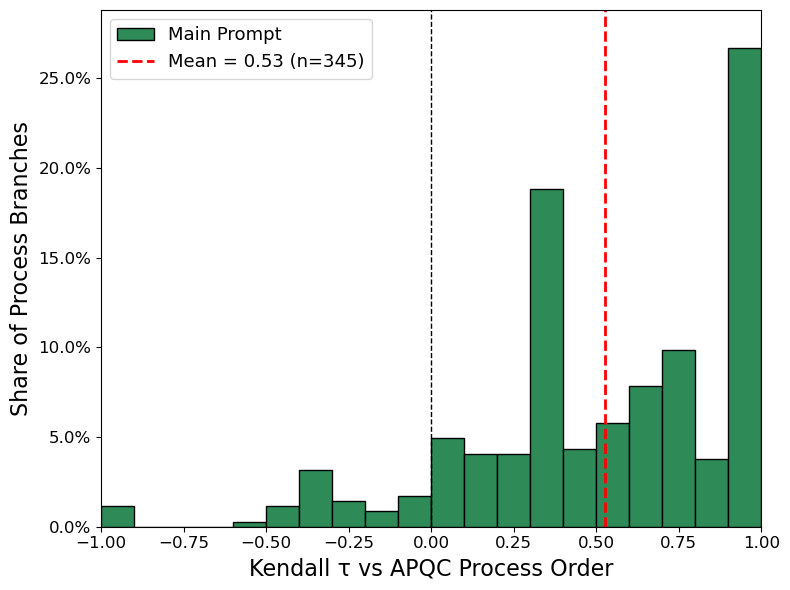

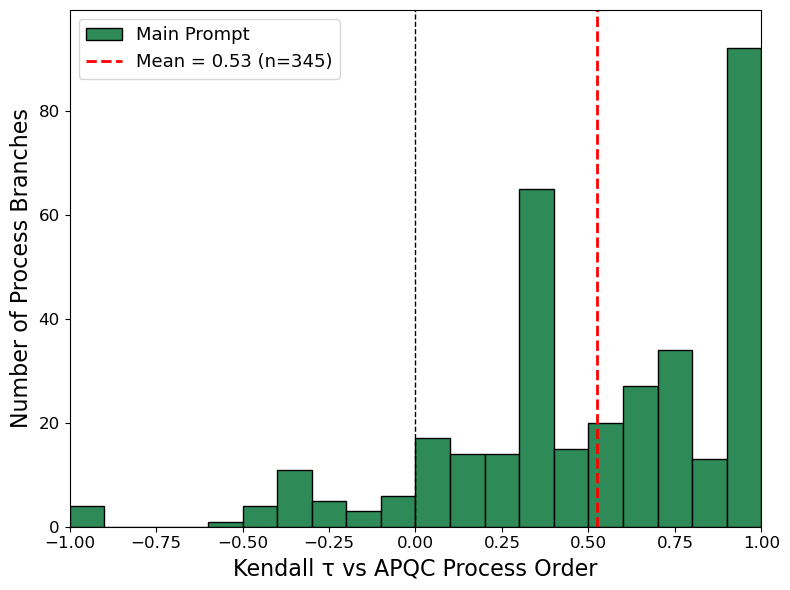

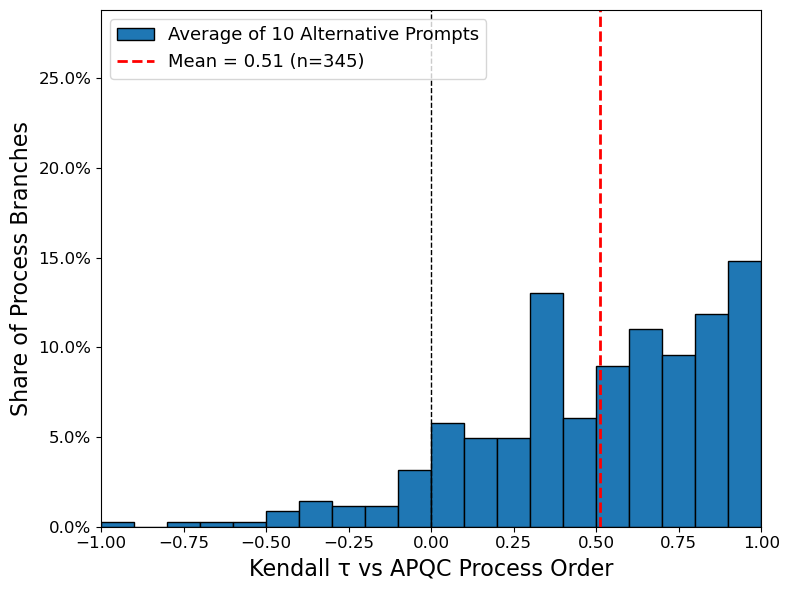

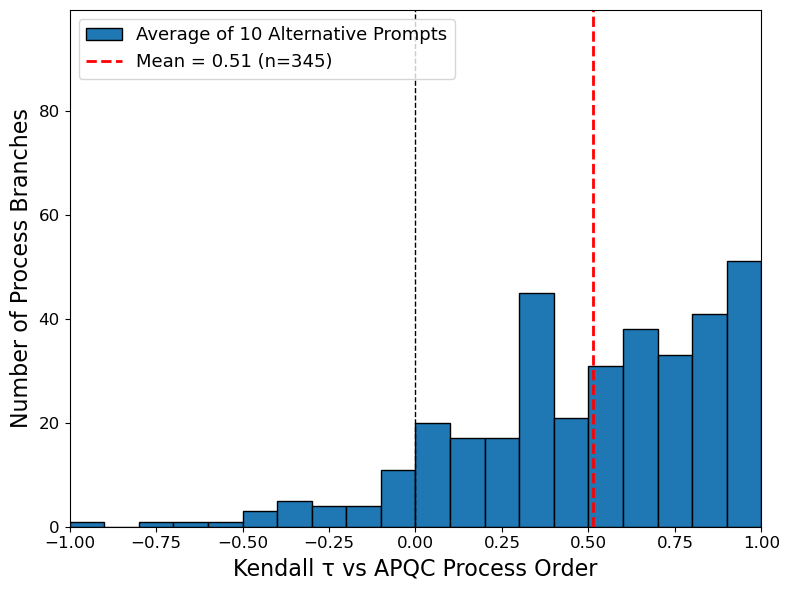

In [12]:
from matplotlib.ticker import PercentFormatter

bins = np.linspace(-1, 1, 21)
# (column, legend label, filename tag, single colour, colormap for the size-shaded version)
panels = [('tau_main',     'Main Prompt',                       'main', 'seagreen', plt.cm.Greens),
          ('tau_alt_mean', 'Average of 10 Alternative Prompts',  'alt',  'tab:blue', plt.cm.Blues)]

# Common y-limit across panels and across the plain / size-shaded versions, so every figure in the
# set is read on the same scale once they are placed side by side in LaTeX.
YMAX = {True:  max((np.histogram(acc.loc[ok, c], bins=bins)[0] / ok.sum()).max() for c, *_ in panels),
        False: max(np.histogram(acc.loc[ok, c], bins=bins)[0].max() for c, *_ in panels)}

def style_axis(ax, col, as_share):
    s = acc.loc[ok, col]
    ax.axvline(s.mean(), color='red', linestyle='--', linewidth=2,
               label=f"Mean = {s.mean():.2f} (n={len(s)})")
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlim(-1, 1); ax.set_ylim(0, YMAX[as_share] * 1.08)
    if as_share:
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_xlabel("Kendall τ vs APQC Process Order", fontsize=16)
    ax.set_ylabel("Share of Process Branches" if as_share else "Number of Process Branches", fontsize=16)
    ax.tick_params(labelsize=12)

def tau_distribution_figure(col, lab, tag, color, as_share):
    s = acc.loc[ok, col]
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.hist(s, bins=bins, weights=np.ones(len(s)) / len(s) if as_share else None,
            color=color, edgecolor='black', label=lab)
    style_axis(ax, col, as_share)
    ax.legend(fontsize=13, loc='upper left')
    fig.tight_layout()
    fig.savefig(f"{output_plot_path}/tau_distribution_{tag}_{'share' if as_share else 'count'}.png",
                dpi=300, bbox_inches='tight')
    plt.show()

for col, lab, tag, color, _ in panels:
    for as_share in [True, False]:
        tau_distribution_figure(col, lab, tag, color, as_share)

### The same distribution, decomposed by how many steps the branch has

Kendall tau is coarse on short branches: with three steps it can only take the values
$\{-1, -1/3, +1/3, +1\}$, so a branch of that length cannot produce a small negative number, only a large
one. Shading each tau bin by branch length shows directly how much of each tail is a short-branch artefact
and how much is genuine disagreement about ordering. Darker bars are longer branches. Shares are taken over
all branches, so the stacked heights reproduce the pooled histogram exactly.

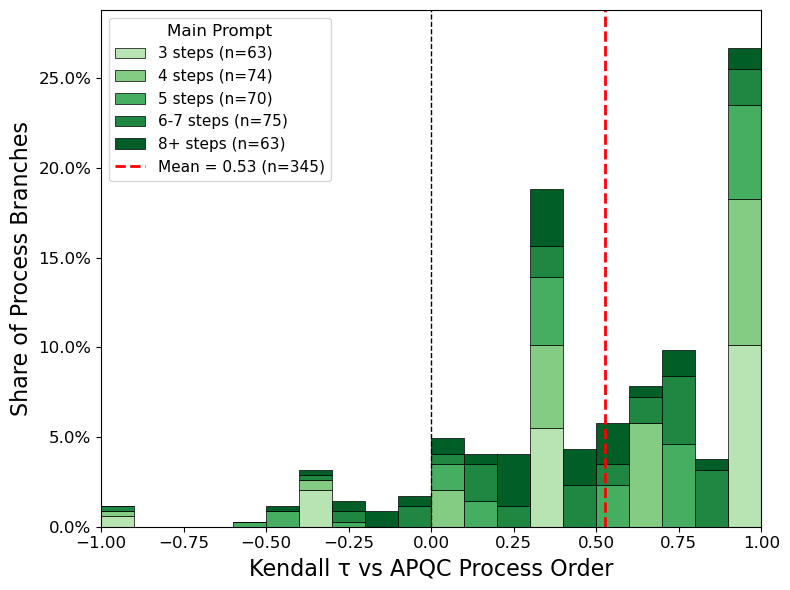

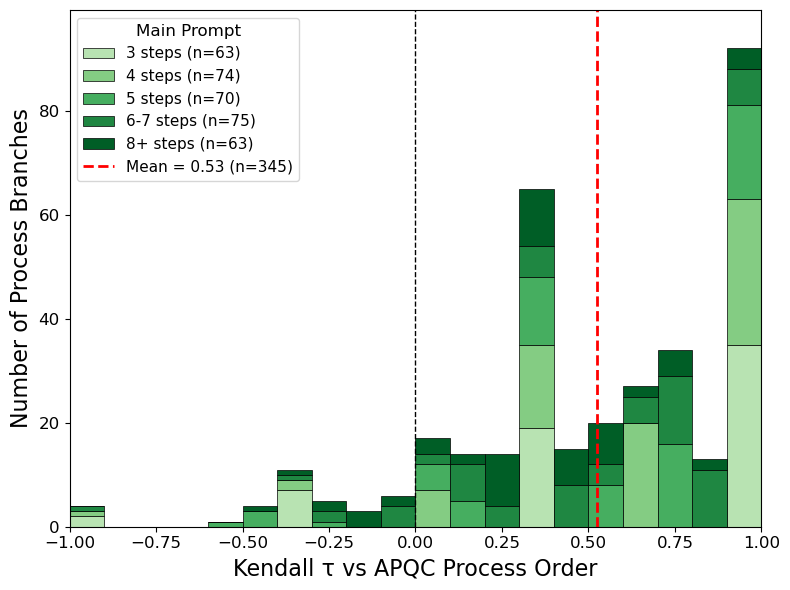

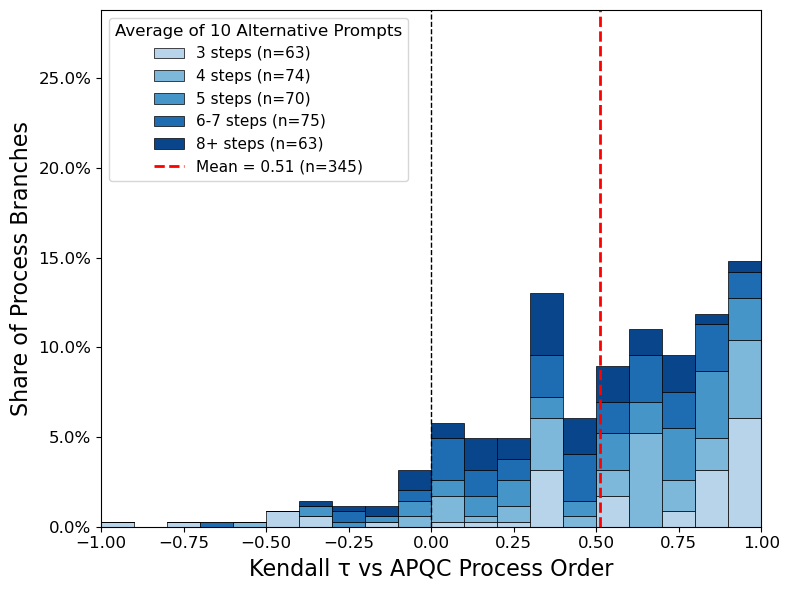

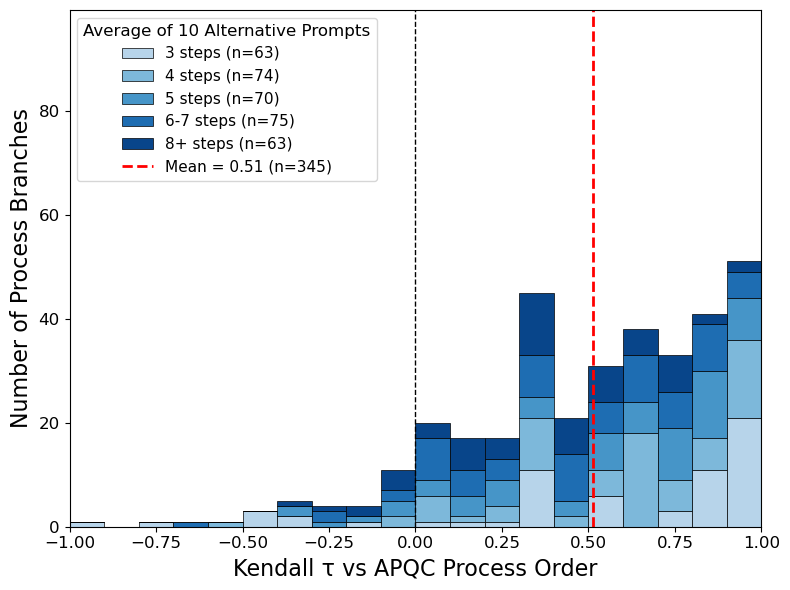

           branches  mean_tau  share_neg  share_tau_eq_1  share_of_all_negatives  smallest_possible_abs_tau
band                                                                                                       
3 steps        63.0     0.587      0.143           0.556                   0.265                      0.333
4 steps        74.0     0.608      0.041           0.378                   0.088                      0.167
5 steps        70.0     0.569      0.071           0.000                   0.147                      0.100
6-7 steps      75.0     0.489      0.107           0.027                   0.235                      0.055
8+ steps       63.0     0.365      0.143           0.000                   0.265                      0.025


In [13]:
SIZE_EDGES  = [(3, 3), (4, 4), (5, 5), (6, 7), (8, 99)]
SIZE_LABELS = ['3 steps', '4 steps', '5 steps', '6-7 steps', '8+ steps']

def tau_distribution_by_size(col, lab, tag, cmap, as_share):
    n_all = int(ok.sum())
    groups = [acc.loc[ok & acc['n_children'].between(lo, hi), col] for lo, hi in SIZE_EDGES]
    shades = cmap(np.linspace(0.30, 0.92, len(groups)))     # light = short branch, dark = long branch
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.hist(groups, bins=bins, stacked=True, color=shades, edgecolor='black', linewidth=0.5,
            weights=[np.ones(len(g)) / n_all for g in groups] if as_share else None,
            label=[f"{sl} (n={len(g)})" for sl, g in zip(SIZE_LABELS, groups)])
    style_axis(ax, col, as_share)
    ax.legend(fontsize=11, loc='upper left', title=lab, title_fontsize=12)
    fig.tight_layout()
    fig.savefig(f"{output_plot_path}/tau_distribution_by_size_{tag}_{'share' if as_share else 'count'}.png",
                dpi=300, bbox_inches='tight')
    plt.show()

for col, lab, tag, _, cmap in panels:
    for as_share in [True, False]:
        tau_distribution_by_size(col, lab, tag, cmap, as_share)

# Companion numbers: what each length band contributes to the tails
band = pd.cut(acc.loc[ok, 'n_children'], bins=[2, 3, 4, 5, 7, 99], labels=SIZE_LABELS, right=True)
tbl = (acc[ok].assign(band=band).groupby('band', observed=True)
       .apply(lambda g: pd.Series({
           'branches': len(g),
           'mean_tau': g['tau_main'].mean(),
           'share_neg': (g['tau_main'] < 0).mean(),
           'share_tau_eq_1': (g['tau_main'] == 1).mean(),
           'share_of_all_negatives': (g['tau_main'] < 0).sum() / (acc.loc[ok, 'tau_main'] < 0).sum(),
           'smallest_possible_abs_tau': 2 / (g['n_children'].mean() * (g['n_children'].mean() - 1)),
       })))
print(tbl.round(3).to_string())

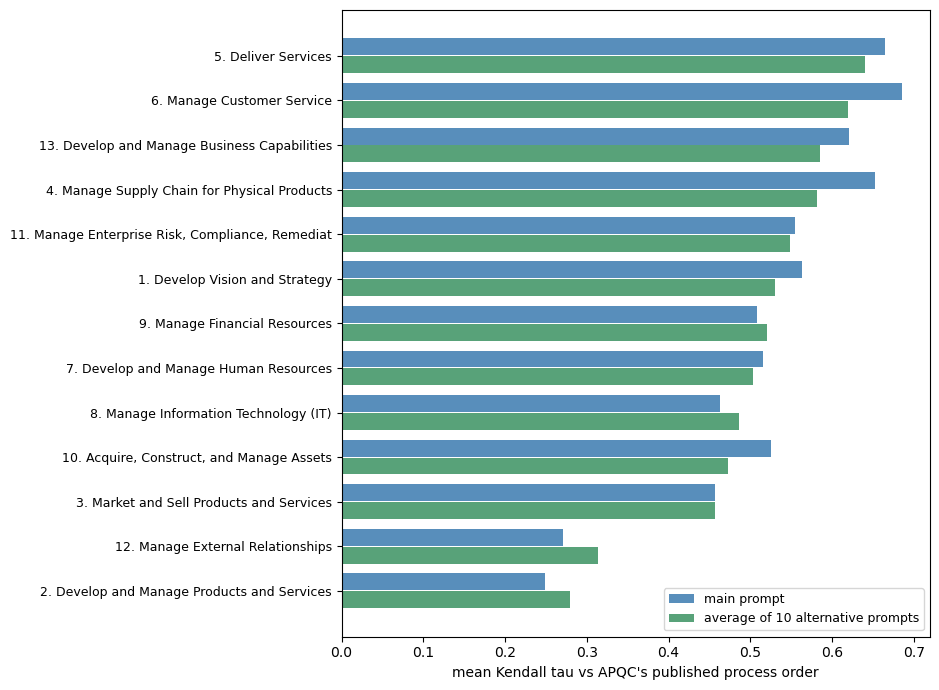

In [14]:
fig, ax = plt.subplots(figsize=(9.5, 7))
cp = cat.sort_values('tau_alt_mean')
y = np.arange(len(cp))
ax.barh(y + 0.20, cp['tau_main'], height=0.38, color='steelblue', alpha=0.9, label='main prompt')
ax.barh(y - 0.20, cp['tau_alt_mean'], height=0.38, color='seagreen', alpha=0.8,
        label='average of 10 alternative prompts')
ax.set_yticks(y)
ax.set_yticklabels([f"{int(c)}. {n[:44]}" for c, n in zip(cp['category'], cp['category_name'])], fontsize=9)
ax.axvline(0, color='0.25', lw=1.2, ls='--')
ax.set_xlabel("mean Kendall tau vs APQC's published process order")
ax.legend(fontsize=9, loc='lower right')
fig.tight_layout()
fig.savefig(f"{output_plot_path}/tau_by_pcf_category.png", dpi=200, bbox_inches='tight')
plt.show()

# 7) Anatomy of the negative-tau branches

The mean is comfortably positive but a visible left tail remains, so it is worth asking what those branches
are rather than assuming. Three things are separated below.

1. **Granularity.** Kendall tau on a short list is coarse. With three steps tau can only take the values
   $\{-1, -1/3, +1/3, +1\}$, so a single inverted pair is already a negative number; with ten steps the same
   single inversion costs 0.022 and leaves tau near $+1$. Branches of three or four steps are about 40% of
   the sample, and a disproportionate share of the negatives sit there.
2. **Magnitude.** Converting tau into a Kendall distance (the count of discordant pairs, and what a random
   ordering would have produced on the same branch) separates "GPT ordered this backwards" from "GPT got a
   couple of adjacent pairs the other way round on a short list".
3. **Content.** Every branch that stays negative on the ten-prompt average is printed with both orderings
   side by side, so the disagreements can be judged. The recurring case is a parent whose children are
   mutually exclusive alternatives or parallel streams rather than steps (accounts payable vs expense
   reimbursements vs corporate cards; acquisition vs merger vs de-merger vs divestiture). No true ordering
   exists there, APQC's listing is a narrative convention, and the sign of tau is close to a coin flip.

In [15]:
d = acc[ok].copy()
d['npairs'] = d['n_children'] * (d['n_children'] - 1) / 2
d['discordant_main'] = ((1 - d['tau_main']) / 2 * d['npairs']).round(0)
d['neg_main'] = d['tau_main'] < 0
d['neg_alt']  = d['tau_alt_mean'] < 0

print(f"main prompt:       tau < 0 in {d['neg_main'].mean():5.1%} | tau == 0 in {(d['tau_main'] == 0).mean():5.1%} "
      f"| tau > 0 in {(d['tau_main'] > 0).mean():5.1%}")
print(f"10-prompt average: tau < 0 in {d['neg_alt'].mean():5.1%} | tau > 0 in {(d['tau_alt_mean'] > 0).mean():5.1%}")
print(f"\nnegative on the main prompt but positive once averaged over the 10 alternatives: "
      f"{int((d['neg_main'] & ~d['neg_alt']).sum())} branches")
print(f"negative under both: {int((d['neg_main'] & d['neg_alt']).sum())} branches")

neg = d[d['neg_main']]
print(f"\n--- how negative are the {len(neg)} negatives? ---")
print(f"  near-ties      -0.25 <= tau < 0 : {int((neg['tau_main'] >= -0.25).sum()):>2} "
      f"({(neg['tau_main'] >= -0.25).mean():.0%} of them)")
print(f"  moderate       -0.50 < tau < -0.25: {int(((neg['tau_main'] < -0.25) & (neg['tau_main'] > -0.5)).sum()):>2}")
print(f"  reversal-like  tau <= -0.50      : {int((neg['tau_main'] <= -0.5).sum()):>2}")

print("\n--- 1) granularity: tau is coarse on short lists ---")
print(f"{'n':>3} {'branches':>9} {'mean tau':>9} {'share<0':>8} {'one-swap cost':>14} {'tau after 1 swap':>17}")
for n, g in d.groupby('n_children'):
    step = 2 / (n * (n - 1))
    print(f"{n:>3} {len(g):>9} {g['tau_main'].mean():>+9.3f} {g['neg_main'].mean():>8.1%} "
          f"{step:>14.3f} {1 - step:>17.3f}")
short = d['n_children'] <= 4
print(f"\nbranches with 3 or 4 steps: {int(short.sum())} ({short.mean():.1%} of the sample); "
      f"they hold {(neg['n_children'] <= 4).mean():.1%} of all negative branches")

print("\n--- 2) magnitude: discordant pairs vs what a random ordering would give ---")
print(neg.groupby('n_children').agg(branches=('tau_main', 'size'), mean_tau=('tau_main', 'mean'),
                                    discordant=('discordant_main', 'mean'),
                                    of_pairs=('npairs', 'mean')).round(2).to_string())
print(f"\nnegatives:     mean {neg['discordant_main'].mean():.1f} discordant of {neg['npairs'].mean():.1f} pairs "
      f"(random would give {neg['npairs'].mean() / 2:.1f})")
print(f"all branches:  mean {d['discordant_main'].mean():.1f} discordant of {d['npairs'].mean():.1f} pairs "
      f"(random would give {d['npairs'].mean() / 2:.1f})")
print(f"\nthe negatives are {len(neg) / len(d):.1%} of branches and contribute "
      f"{neg['discordant_main'].sum() / d['discordant_main'].sum():.1%} of all discordant pairs")

main prompt:       tau < 0 in  9.9% | tau == 0 in  4.1% | tau > 0 in 86.1%
10-prompt average: tau < 0 in  9.0% | tau > 0 in 90.1%

negative on the main prompt but positive once averaged over the 10 alternatives: 12 branches
negative under both: 22 branches

--- how negative are the 34 negatives? ---
  near-ties      -0.25 <= tau < 0 : 14 (41% of them)
  moderate       -0.50 < tau < -0.25: 15
  reversal-like  tau <= -0.50      :  5

--- 1) granularity: tau is coarse on short lists ---
  n  branches  mean tau  share<0  one-swap cost  tau after 1 swap
  3        63    +0.587    14.3%          0.333             0.667
  4        74    +0.608     4.1%          0.167             0.833
  5        70    +0.569     7.1%          0.100             0.900
  6        35    +0.421    14.3%          0.067             0.933
  7        40    +0.548     7.5%          0.048             0.952
  8        27    +0.365    11.1%          0.036             0.964
  9        15    +0.378    13.3%          0.028  

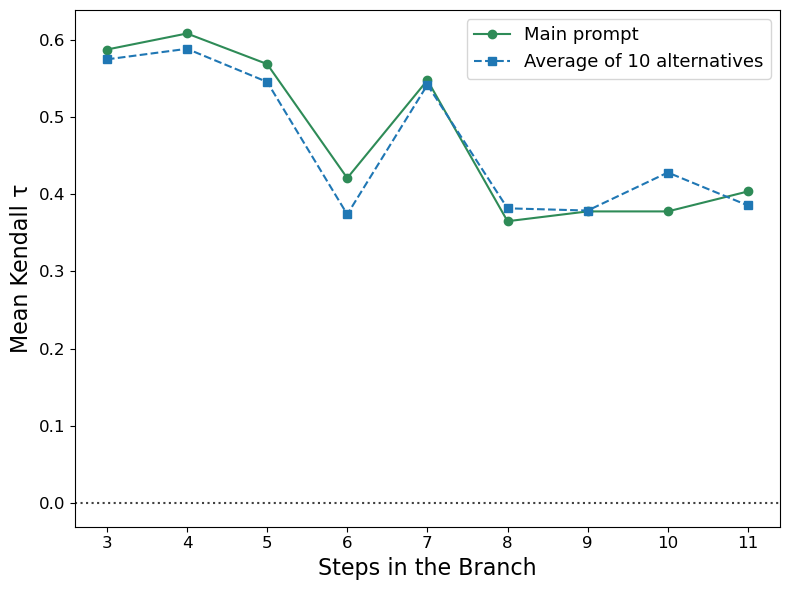

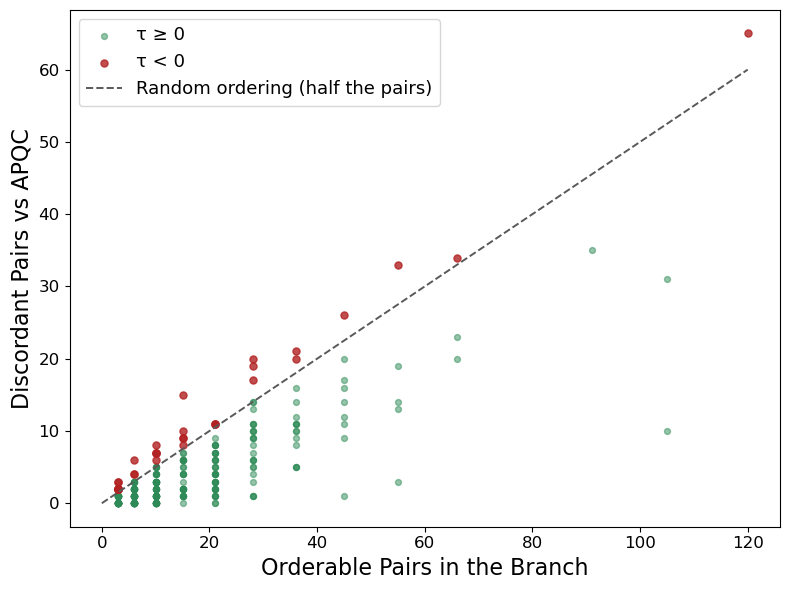

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
bysize = (d.groupby('n_children')
          .agg(main=('tau_main', 'mean'), alt=('tau_alt_mean', 'mean'), n=('tau_main', 'size'))
          .reset_index())
bysize = bysize[bysize['n'] >= 5]
ax.plot(bysize['n_children'], bysize['main'], 'o-', color='seagreen', label='Main prompt')
ax.plot(bysize['n_children'], bysize['alt'], 's--', color='tab:blue', label='Average of 10 alternatives')
ax.axhline(0, color='0.25', ls=':', lw=1.5)
ax.set_xlabel("Steps in the Branch", fontsize=16)
ax.set_ylabel("Mean Kendall τ", fontsize=16)
ax.tick_params(labelsize=12); ax.legend(fontsize=13)
fig.tight_layout()
fig.savefig(f"{output_plot_path}/tau_by_branch_length.png", dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(d.loc[~d['neg_main'], 'npairs'], d.loc[~d['neg_main'], 'discordant_main'],
           s=18, color='seagreen', alpha=0.5, label='τ ≥ 0')
ax.scatter(d.loc[d['neg_main'], 'npairs'], d.loc[d['neg_main'], 'discordant_main'],
           s=26, color='firebrick', alpha=0.8, label='τ < 0')
lim = d['npairs'].max()
ax.plot([0, lim], [0, lim / 2], color='0.35', ls='--', lw=1.4, label='Random ordering (half the pairs)')
ax.set_xlabel("Orderable Pairs in the Branch", fontsize=16)
ax.set_ylabel("Discordant Pairs vs APQC", fontsize=16)
ax.tick_params(labelsize=12); ax.legend(fontsize=13)
fig.tight_layout()
fig.savefig(f"{output_plot_path}/negative_tau_discordant_pairs.png", dpi=300, bbox_inches='tight')
plt.show()

In [17]:
print("--- 3) content: every branch negative on the 10-prompt average, both orderings shown ---\n")
worst = d[d['neg_alt']].sort_values('tau_alt_mean')
for _, r in worst.iterrows():
    p = r['parent_hierarchy_id']
    gp = gpt_pos[MAIN_PROMPT][p]
    print(f"### {p}  {r['parent_name']}   "
          f"(main tau {r['tau_main']:+.2f}, 10-prompt avg {r['tau_alt_mean']:+.2f}, n={int(r['n_children'])})")
    for c in sets[p]['children']:
        print(f"     APQC {c['hierarchy_id'].split('.')[-1]:>2} -> GPT {gp[c['hierarchy_id']]:>2}   {c['name'][:66]}")
    print()

worst[['parent_hierarchy_id', 'parent_name', 'category', 'category_name', 'n_children',
       'tau_main', 'tau_alt_mean', 'tau_alt_sd', 'discordant_main', 'npairs']].to_csv(
    f"{output_data_path}/negative_tau_branches.csv", index=False)
print(f"saved {len(worst)} branches to negative_tau_branches.csv")

--- 3) content: every branch negative on the 10-prompt average, both orderings shown ---

### 10.1.4  Manage facilities operations   (main tau -1.00, 10-prompt avg -1.00, n=3)
     APQC  1 -> GPT  3   Relocate people
     APQC  2 -> GPT  2   Relocate material and tools
     APQC  3 -> GPT  1   Provide facility access and security

### 9.6  Process accounts payable and expense reimbursements   (main tau -1.00, 10-prompt avg -0.73, n=3)
     APQC  1 -> GPT  3   Process accounts payable (AP)
     APQC  2 -> GPT  2   Process expense reimbursements
     APQC  3 -> GPT  1   Manage corporate credit cards

### 13.9.3  Monitor and manage EHS program   (main tau -1.00, 10-prompt avg -0.67, n=6)
     APQC  1 -> GPT  6   Manage EHS costs and benefits
     APQC  2 -> GPT  5   Measure and report EHS performance
     APQC  3 -> GPT  4   Implement emergency response program
     APQC  4 -> GPT  3   Implement pollution prevention program
     APQC  5 -> GPT  2   Train and educate functional employees
 

# 8) LaTeX table

In [18]:
def col_stats(mask):
    s = acc.loc[ok & mask]
    return {'n_sets': len(s), 'n_elem': int(s['n_children'].sum()),
            'tau_main': s['tau_main'].mean(), 'tau_alt': s['tau_alt_mean'].mean(),
            'tau_null': s['tau_null_mean'].mean(),
            'adj_main': s[f'adj_{MAIN_PROMPT}'].mean(), 'adj_alt': s['adj_alt_mean'].mean(),
            'exact_main': s[f'exact_{MAIN_PROMPT}'].mean(),
            'share_pos_main': (s['tau_main'] > 0).mean(), 'share_pos_alt': (s['tau_alt_mean'] > 0).mean()}

cols = [('All branches', col_stats(pd.Series(True, index=acc.index))),
        ('Operating (1--6)', col_stats(acc['category'].isin(OPERATING_CATS))),
        (r'Mgmt \& support (7--13)', col_stats(acc['category'].isin(SUPPORT_CATS)))]

def row(label, key, fmt='{:+.3f}'):
    return f"{label} & " + " & ".join(fmt.format(c[1][key]) for c in cols) + r" \\"

tex = [r"\setlength{\tabcolsep}{8pt}",
       r"\small",
       r"\begin{tabular}{lccc}",
       r"\toprule",
       " & " + " & ".join(c[0] for c in cols) + r" \\",
       r"\cmidrule(lr){2-4}",
       r" & (1) & (2) & (3) \\",
       r"\midrule",
       r"\addlinespace",
       r"\multicolumn{4}{l}{\textit{Mean Kendall $\tau$ against APQC's published process order}} \\",
       r"\addlinespace",
       row(r"\quad Main prompt (Prompt 0)", 'tau_main'),
       row(r"\quad Average of 10 alternative prompts", 'tau_alt'),
       row(r"\quad Random ordering (null)", 'tau_null'),
       r"\addlinespace",
       r"\hline\\[-1.25em]",
       r"\multicolumn{4}{l}{\textit{Other overlap measures}} \\",
       r"\addlinespace",
       row(r"\quad Adjacent-pair agreement, main prompt (null 0.5)", 'adj_main', '{:.3f}'),
       row(r"\quad Adjacent-pair agreement, 10-prompt average", 'adj_alt', '{:.3f}'),
       row(r"\quad Exact-order recovery, main prompt", 'exact_main', '{:.3f}'),
       row(r"\quad Share of branches with $\tau > 0$, main prompt", 'share_pos_main', '{:.3f}'),
       row(r"\quad Share of branches with $\tau > 0$, 10-prompt average", 'share_pos_alt', '{:.3f}'),
       r"\hline\\[-1.25em]",
       row("Process branches", 'n_sets', '{:,.0f}'),
       row("Process elements ordered", 'n_elem', '{:,.0f}'),
       r"\bottomrule",
       r"\end{tabular}"]

with open(f"{output_table_path}/apqc_pcf_ordering_validation.tex", 'w') as f:
    f.write("\n".join(tex) + "\n")
print("\n".join(tex))

\setlength{\tabcolsep}{8pt}
\small
\begin{tabular}{lccc}
\toprule
 & All branches & Operating (1--6) & Mgmt \& support (7--13) \\
\cmidrule(lr){2-4}
 & (1) & (2) & (3) \\
\midrule
\addlinespace
\multicolumn{4}{l}{\textit{Mean Kendall $\tau$ against APQC's published process order}} \\
\addlinespace
\quad Main prompt (Prompt 0) & +0.526 & +0.541 & +0.516 \\
\quad Average of 10 alternative prompts & +0.512 & +0.512 & +0.512 \\
\quad Random ordering (null) & +0.000 & +0.000 & +0.000 \\
\addlinespace
\hline\\[-1.25em]
\multicolumn{4}{l}{\textit{Other overlap measures}} \\
\addlinespace
\quad Adjacent-pair agreement, main prompt (null 0.5) & 0.700 & 0.726 & 0.682 \\
\quad Adjacent-pair agreement, 10-prompt average & 0.697 & 0.704 & 0.693 \\
\quad Exact-order recovery, main prompt & 0.243 & 0.277 & 0.221 \\
\quad Share of branches with $\tau > 0$, main prompt & 0.861 & 0.839 & 0.875 \\
\quad Share of branches with $\tau > 0$, 10-prompt average & 0.901 & 0.898 & 0.904 \\
\hline\\[-1.25em]
Proc

In [19]:
print("Saved:")
for f in sorted(os.listdir(output_data_path)):
    print("  data  ->", f"{output_data_path}/{f}")
for f in sorted(os.listdir(output_plot_path)):
    print("  plot  ->", f"{output_plot_path}/{f}")
print("  table ->", f"{output_table_path}/apqc_pcf_ordering_validation.tex")

Saved:
  data  -> ../data/computed_objects/apqc_pcf_ordering/category_summary.csv
  data  -> ../data/computed_objects/apqc_pcf_ordering/gpt_orderings
  data  -> ../data/computed_objects/apqc_pcf_ordering/level_summary.csv
  data  -> ../data/computed_objects/apqc_pcf_ordering/negative_tau_branches.csv
  data  -> ../data/computed_objects/apqc_pcf_ordering/null_aggregate_draws.csv
  data  -> ../data/computed_objects/apqc_pcf_ordering/ordering_accuracy.csv
  data  -> ../data/computed_objects/apqc_pcf_ordering/pcf_elements.csv
  data  -> ../data/computed_objects/apqc_pcf_ordering/prompt_summary.csv
  data  -> ../data/computed_objects/apqc_pcf_ordering/segment_summary.csv
  data  -> ../data/computed_objects/apqc_pcf_ordering/sibling_sets.csv
  data  -> ../data/computed_objects/apqc_pcf_ordering/summary_stats.csv
  plot  -> ../writeup/plots/apqc_pcf_ordering/.DS_Store
  plot  -> ../writeup/plots/apqc_pcf_ordering/negative_tau_discordant_pairs.png
  plot  -> ../writeup/plots/apqc_pcf_ordering/

# 9) Face validity: best and worst recovered process branches

In [20]:
fv = acc[ok & (acc['n_children'] >= 5)].copy()
print(f"--- TOP 15 best-recovered branches by 10-prompt average (of {len(fv)} with >= 5 steps) ---")
for _, r in fv.sort_values('tau_alt_mean', ascending=False).head(15).iterrows():
    print(f"  alt-avg {r['tau_alt_mean']:+.2f} | main {r['tau_main']:+.2f} | n {int(r['n_children']):>2} | "
          f"{r['parent_hierarchy_id']:>9}  {r['parent_name'][:58]}")
print("\n--- BOTTOM 15 worst-recovered branches ---")
for _, r in fv.sort_values('tau_alt_mean').head(15).iterrows():
    print(f"  alt-avg {r['tau_alt_mean']:+.2f} | main {r['tau_main']:+.2f} | n {int(r['n_children']):>2} | "
          f"{r['parent_hierarchy_id']:>9}  {r['parent_name'][:58]}")

ex = fv.sort_values('tau_alt_mean', ascending=False).iloc[0]['parent_hierarchy_id']
info, gp = sets[ex], gpt_pos[MAIN_PROMPT][ex]
print(f"\nExample -- {ex} {info['parent_name']}")
print(f"  {'APQC order':<52}  GPT position")
for c in info['children']:
    print(f"  {c['hierarchy_id']:>10} {c['name'][:40]:<41} {gp[c['hierarchy_id']]}")

--- TOP 15 best-recovered branches by 10-prompt average (of 208 with >= 5 steps) ---
  alt-avg +1.00 | main +1.00 | n  7 |    11.1.3  Manage business unit and function risk
  alt-avg +1.00 | main +1.00 | n  5 |       9.1  Perform planning and management accounting
  alt-avg +1.00 | main +1.00 | n  5 |     9.4.2  Perform capital project accounting
  alt-avg +1.00 | main +1.00 | n  5 |       6.2  Plan and manage customer service contacts
  alt-avg +1.00 | main +1.00 | n  5 |    13.4.3  Implement change
  alt-avg +1.00 | main +1.00 | n  5 |       8.6  Deploy services/solutions
  alt-avg +0.99 | main +0.87 | n  6 |     3.4.3  Establish overall sales budgets
  alt-avg +0.96 | main +1.00 | n  7 |   8.5.4.1  Execute IT service/solution development lifecycle
  alt-avg +0.94 | main +1.00 | n  5 |       1.1  Define the business concept and long-term vision
  alt-avg +0.92 | main +0.96 | n 10 |     6.3.2  Process warranty claims
  alt-avg +0.92 | main +0.90 | n  7 |     5.2.3  Enable service deli

## Reading the results

**What this test does.** It scores the *ordering instrument* against sequences that practitioners wrote
down, on a corpus the instrument has never touched. That is a different and stronger claim than the
cross-prompt Kendall tau in the prompt-robustness appendix, which establishes that the orderings are stable,
not that they are right. Running all eleven prompts here means the two claims are made on the same footing:
the same prompt set, scored against a human benchmark instead of against each other.

**What it does not do.** It does not validate the specific O\*NET orderings used in the paper, and it cannot:
no crosswalk between PCF elements and O\*NET tasks is used here. It validates the procedure. Two further
limits belong in any writeup. First, PCF sibling order is APQC's editorial convention; it is a workflow claim
in transactional branches and closer to a checklist in strategic ones, which is why the category table is
reported alongside the pooled number. Second, PCF coverage is enterprise process work (finance, procurement,
HR, IT, supply chain) and thin on frontline, care, and craft occupations, so accuracy here speaks loudest for
the white-collar occupations that carry most of the AI-exposure variation.

**Natural follow-ons.** (i) Correlate PCF category accuracy with the GWA-stage sequence-ability index from
`onet_gwaStage_sequenceability.ipynb`, via an LLM crosswalk from PCF branches to SOC groups, to check that
the instrument is accurate exactly where workflows are sequential. (ii) Re-run Prediction #3 with adjacency
defined by PCF position instead of GPT position on the subset of DWAs that map to PCF elements.